# Tutorial: MILK sampling

We use [scanpy](https://scanpy.readthedocs.io/en/stable/) to read/write 10X data. Import numpy and scanpy in addlition to screcode.

In [7]:
import sys
sys.path.append("../..")

In [8]:
import warnings

import numpy as np
import scanpy as sc
import screcode

warnings.simplefilter('ignore')

Read in the count matrix into an [AnnData](https://anndata.readthedocs.io/en/latest/) object. 

In [3]:
input_filename = 'data/10k_PBMC_3p_nextgem_Chromium_Controller_filtered_feature_bc_matrix.h5'
adata = sc.read_10x_h5(input_filename)
adata.layers["Raw"] = adata.X.toarray()
adata

AnnData object with n_obs × n_vars = 11485 × 36601
    var: 'gene_ids', 'feature_types', 'genome'
    layers: 'Raw'

## Preprocess the data with Scanpy

In [4]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata, chunked=False, zero_center=False)
sc.pp.neighbors(adata, n_pcs=50)
sc.tl.leiden(adata, resolution=0.3)
sc.tl.umap(adata)

## Sampling

In [5]:
recode = screcode.RECODE()

In [12]:
n_samples = 2000
milk_idx = recode.milk_sampling(adata, n_samples=n_samples, thresh_percentile=1)
rand_idx = np.sort(np.random.choice(adata.X.shape[0], n_samples, replace=False))

Distance threshold of Milk sampling: 0.0025
Number of accepted data of Milk sampling: 3074


In [14]:
print(milk_idx)
print(rand_idx)

[    3    16    18 ... 11471 11480 11481]
[    6    14    18 ... 11474 11478 11481]


## Result

In [15]:
milk_adata = adata[milk_idx]
rand_adata = adata[rand_idx]

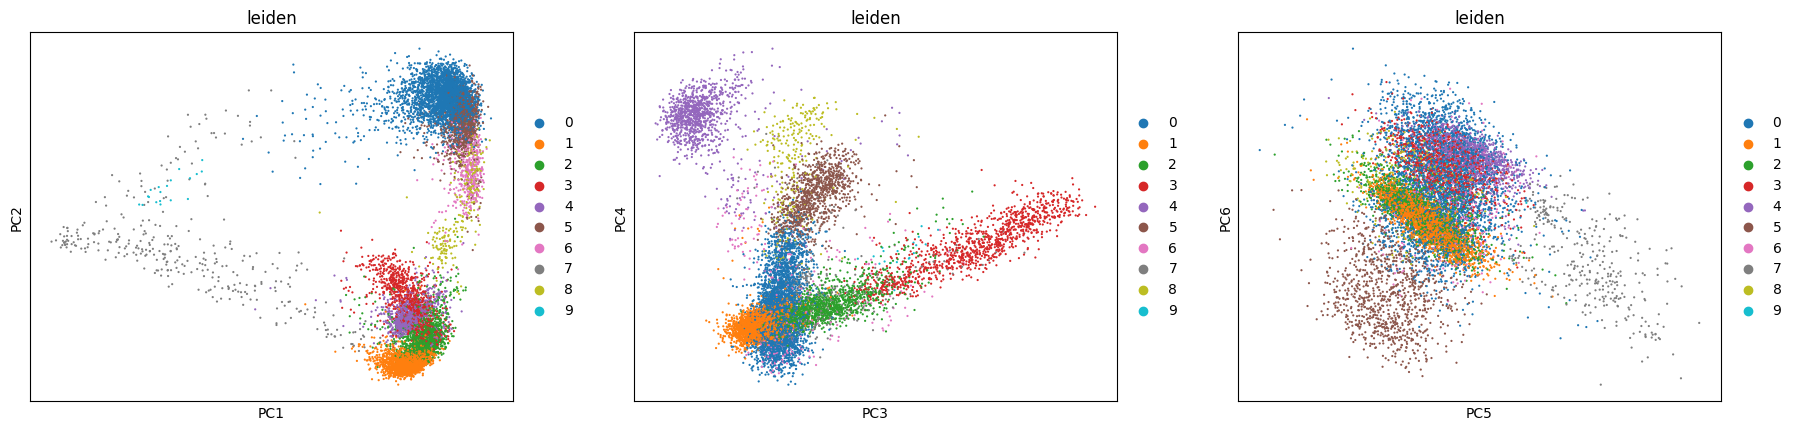

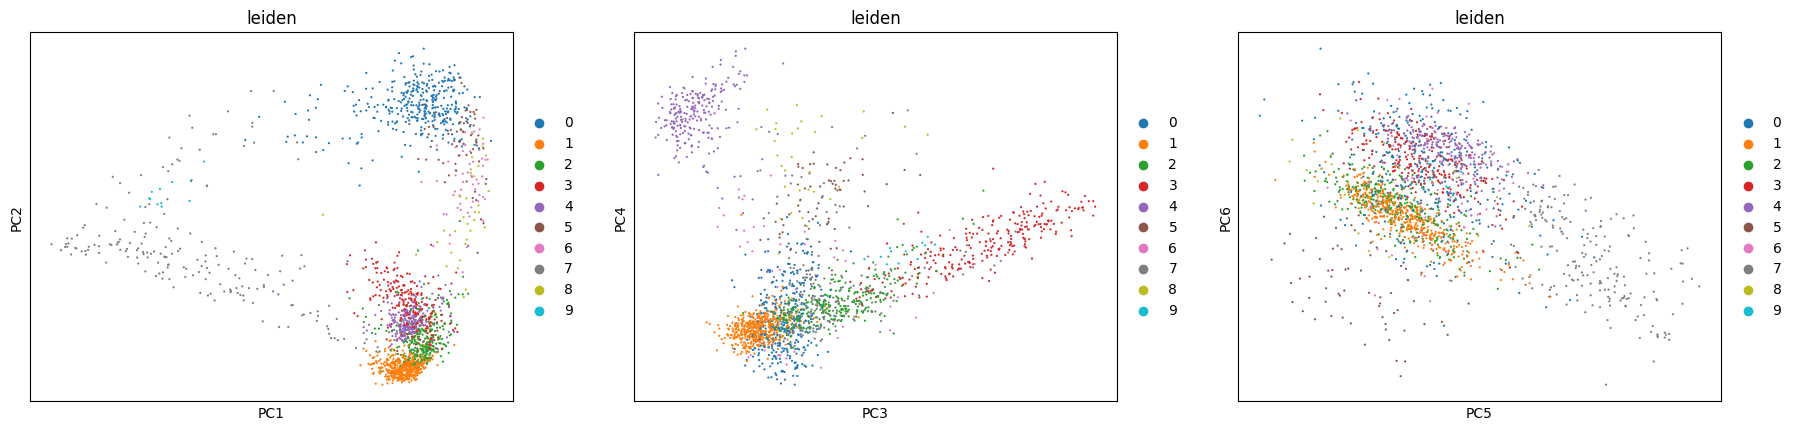

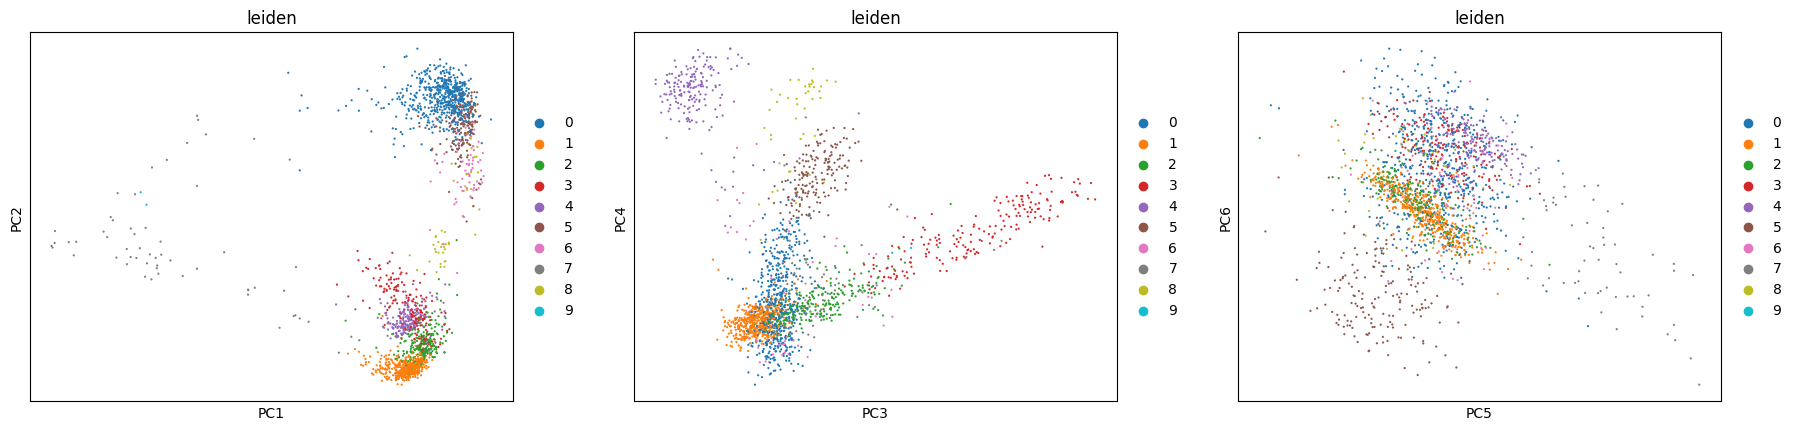

In [16]:
sc.pl.pca(adata, components=['1,2', '3,4', '5,6'], color=['leiden'], size=10)
sc.pl.pca(milk_adata, components=['1,2','3,4','5,6'], color=["leiden"], size=10)
sc.pl.pca(rand_adata, components=['1,2','3,4','5,6'], color=["leiden"], size=10)

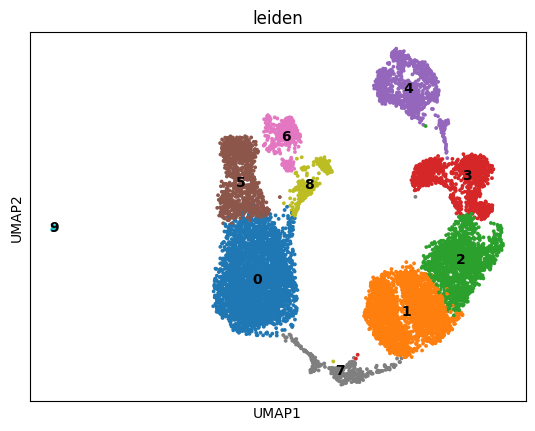

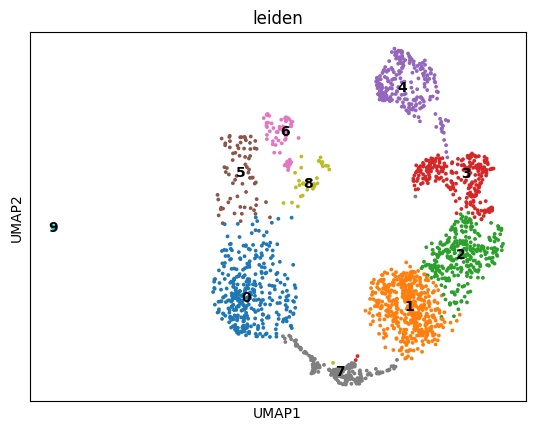

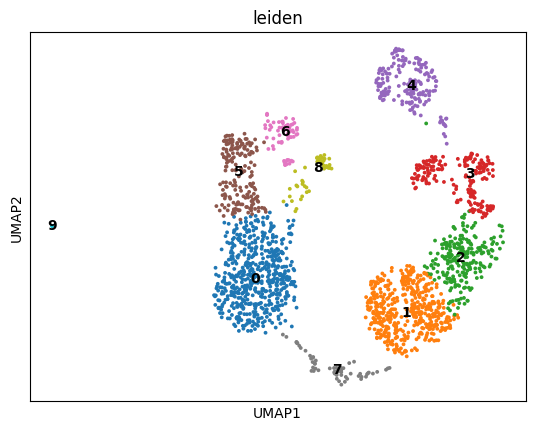

In [20]:
sc.pl.umap(adata, color=['leiden'],legend_loc='on data', size=30)
sc.pl.umap(milk_adata, color=['leiden'],legend_loc='on data', size=30)
sc.pl.umap(rand_adata, color=['leiden'],legend_loc='on data', size=30)

In [44]:
import pandas as pd
counts = [ad.obs["leiden"].value_counts().rename_axis(None) for ad in [adata, milk_adata, rand_adata]]
df = pd.concat(counts, axis=1, keys=["Total", "Milk sampling", "Random sampling"])
print("Cell number in each cluster:")
df

Cell number in each cluster:


,Total,Milk sampling,Random sampling
0,3350,352,572
1,2596,479,462
2,1455,305,238
3,1076,255,190
4,1048,243,189
5,958,69,178
6,387,61,65
7,334,191,59
8,262,33,45
9,19,12,2
